In [1]:
# Import necessary libraries
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import warnings
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'seaborn'

# Data Collection

In [ ]:
import pandas as pd

df = pd.read_csv("Heart_Disease_Prediction.csv")

df.head()

,index,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


#  Data Preprocessing

In [ ]:
df.describe()

,index,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium
count,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.000000,270.00000,270.000000,270.000000,270.000000
mean,134.500000,54.433333,0.677778,3.174074,131.344444,249.659259,0.148148,1.022222,149.677778,0.329630,1.05000,1.585185,0.670370,4.696296
std,78.086491,9.109067,0.468195,0.950090,17.861608,51.686237,0.355906,0.997891,23.165717,0.470952,1.14521,0.614390,0.943896,1.940659
min,0.000000,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.00000,1.000000,0.000000,3.000000
25%,67.250000,48.000000,0.000000,3.000000,120.000000,213.000000,0.000000,0.000000,133.000000,0.000000,0.00000,1.000000,0.000000,3.000000
50%,134.500000,55.000000,1.000000,3.000000,130.000000,245.000000,0.000000,2.000000,153.500000,0.000000,0.80000,2.000000,0.000000,3.000000
75%,201.750000,61.000000,1.000000,4.000000,140.000000,280.000000,0.000000,2.000000,166.000000,1.000000,1.60000,2.000000,1.000000,7.000000
max,269.000000,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.20000,3.000000,3.000000,7.000000


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 270 entries, 0 to 269
Data columns (total 15 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   index                    270 non-null    int64  
 1   Age                      270 non-null    int64  
 2   Sex                      270 non-null    int64  
 3   Chest pain type          270 non-null    int64  
 4   BP                       270 non-null    int64  
 5   Cholesterol              270 non-null    int64  
 6   FBS over 120             270 non-null    int64  
 7   EKG results              270 non-null    int64  
 8   Max HR                   270 non-null    int64  
 9   Exercise angina          270 non-null    int64  
 10  ST depression            270 non-null    float64
 11  Slope of ST              270 non-null    int64  
 12  Number of vessels fluro  270 non-null    int64  
 13  Thallium                 270 non-null    int64  
 14  Heart Disease            270 non-null

In [ ]:
df.shape

(270, 15)

In [ ]:
# Checking for missing values.
df.isnull().values.any()

np.False_

In [ ]:
# Checking for imbalanced data based on sex.
df["Sex"].value_counts()

Sex
1    183
0     87
Name: count, dtype: int64

In [ ]:
# Checking for imbalanced data based on outcome.
df['Heart Disease'].value_counts()

Heart Disease
Absence     150
Presence    120
Name: count, dtype: int64

<Axes: xlabel='Heart Disease', ylabel='count'>

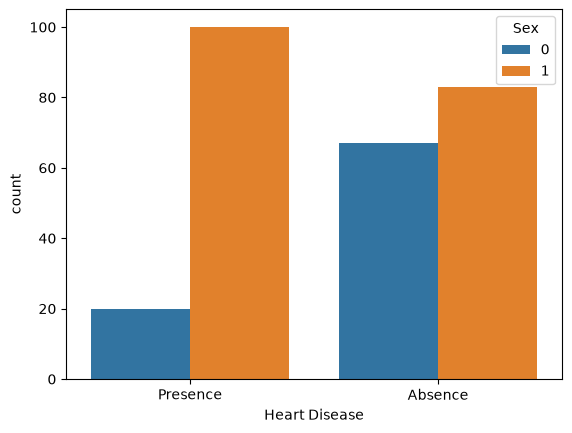

In [ ]:
sns.countplot(x=df['Heart Disease'],hue='Sex',data=df)

<Axes: xlabel='Heart Disease', ylabel='count'>

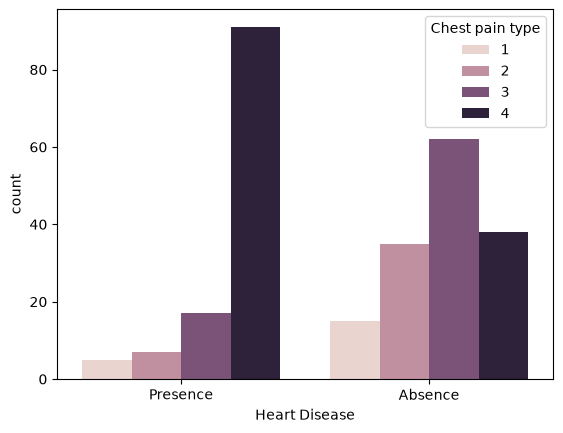

In [ ]:
sns.countplot(x=df['Heart Disease'],hue='Chest pain type',data=df)

<Axes: xlabel='Sex', ylabel='count'>

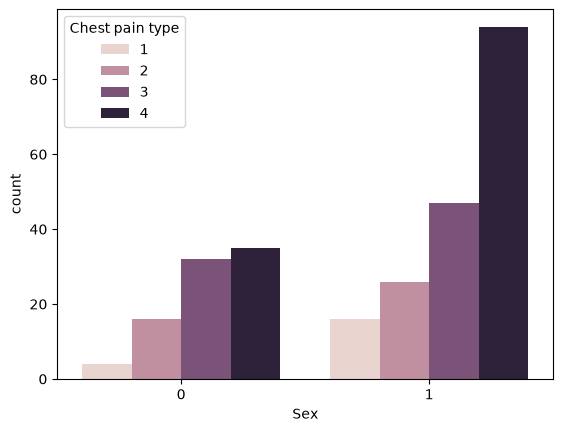

In [ ]:
sns.countplot(x=df['Sex'],hue='Chest pain type',data=df)

<Axes: xlabel='Sex', ylabel='BP'>

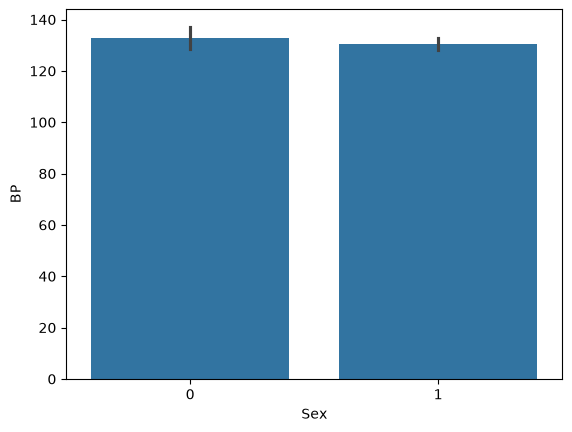

In [ ]:
sns.barplot(x=df['Sex'],y=df['BP'],data=df)

<Axes: xlabel='Sex', ylabel='Cholesterol'>

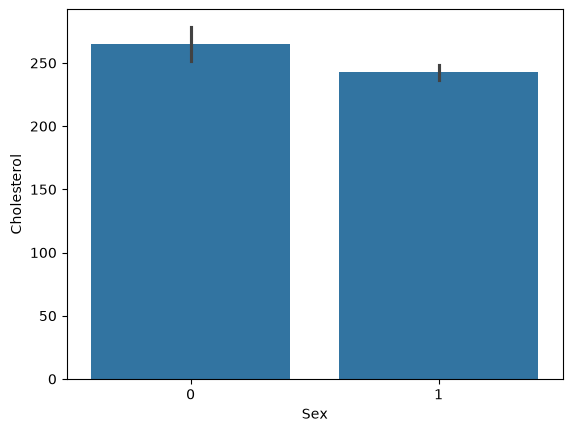

In [ ]:
sns.barplot(x=df['Sex'],y=df['Cholesterol'],data=df)

<Axes: xlabel='Heart Disease', ylabel='Cholesterol'>

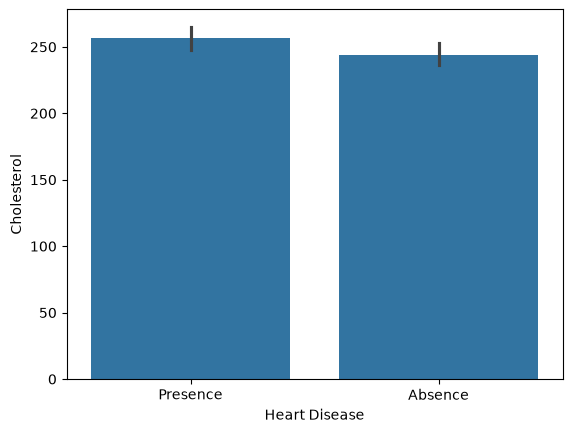

In [ ]:
sns.barplot(x=df['Heart Disease'],y=df['Cholesterol'],data=df)

<Axes: xlabel='Heart Disease', ylabel='BP'>

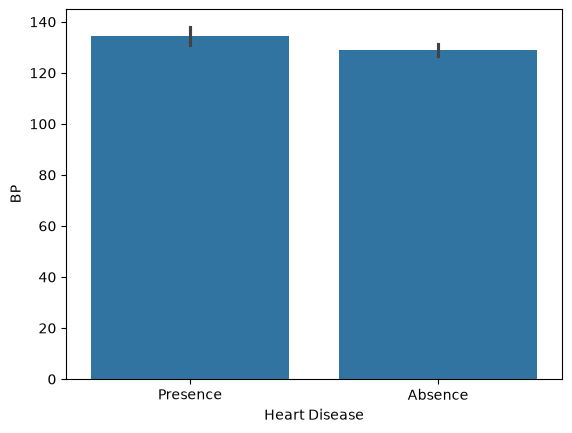

In [ ]:
sns.barplot(x=df['Heart Disease'],y=df['BP'],data=df)

<Axes: xlabel='Age', ylabel='BP'>

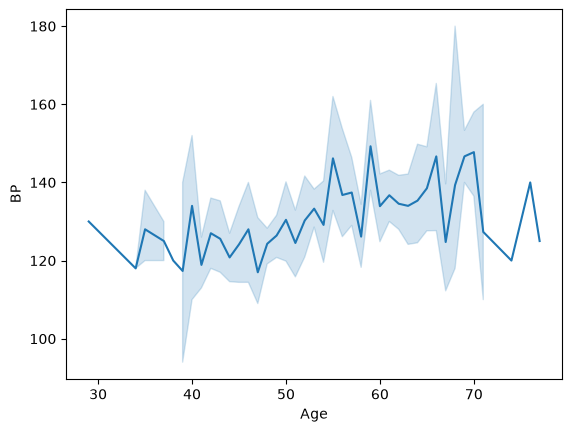

In [ ]:
sns.lineplot(x=df['Age'],y=df['BP'],data=df)

<Axes: xlabel='Age', ylabel='Cholesterol'>

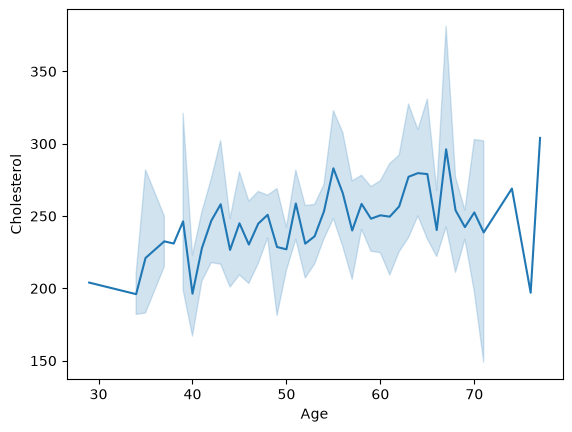

In [ ]:
sns.lineplot(x=df['Age'],y=df['Cholesterol'],data=df)

<Axes: xlabel='Age', ylabel='ST depression'>

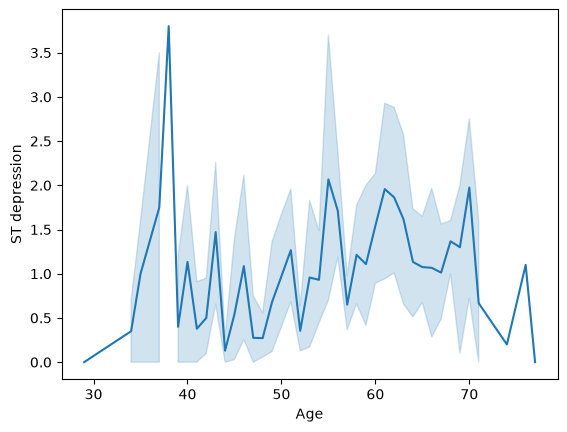

In [ ]:
sns.lineplot(x=df['Age'],y=df['ST depression'],data=df)

<Axes: xlabel='Sex', ylabel='ST depression'>

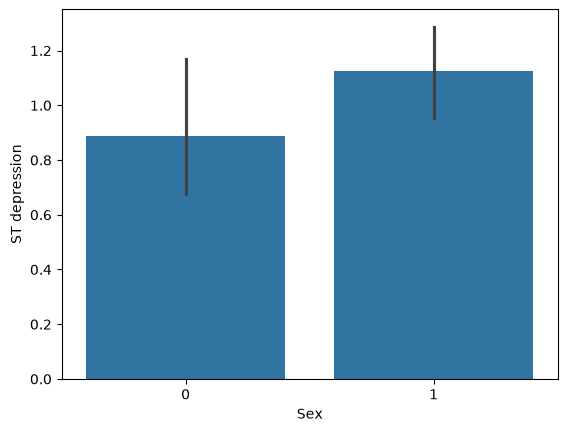

In [ ]:
sns.barplot(x=df['Sex'],y=df['ST depression'],data=df)

<Axes: xlabel='Heart Disease', ylabel='Exercise angina'>

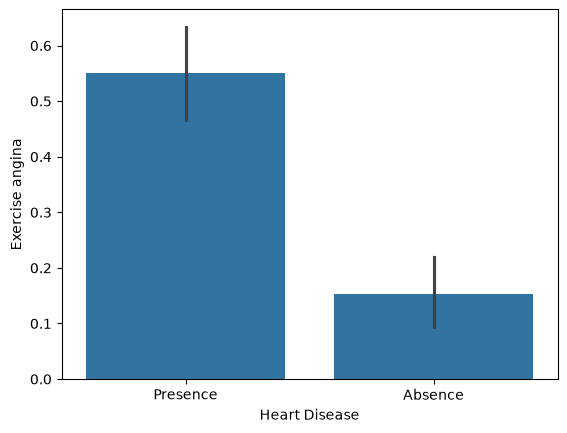

In [ ]:
sns.barplot(x=df['Heart Disease'],y=df['Exercise angina'],data=df)

<Axes: xlabel='Sex', ylabel='Exercise angina'>

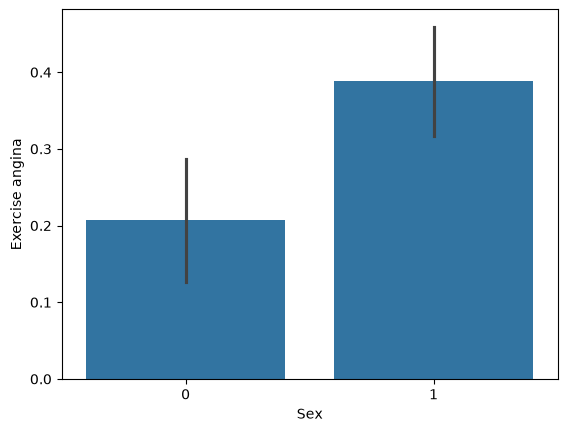

In [ ]:
sns.barplot(x=df['Sex'],y=df['Exercise angina'],data=df)

<Axes: xlabel='Heart Disease', ylabel='Number of vessels fluro'>

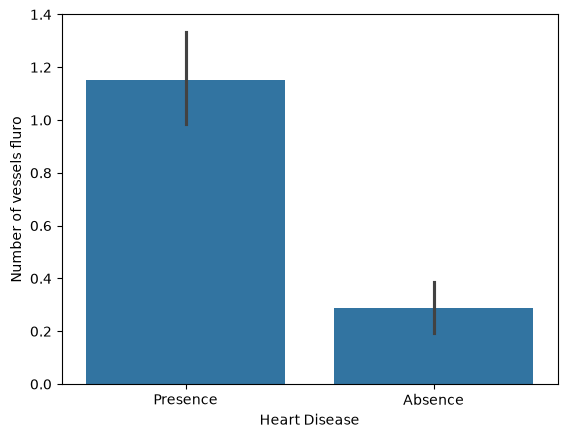

In [ ]:
sns.barplot(x=df['Heart Disease'],y=df['Number of vessels fluro'],data=df)

<Axes: xlabel='Heart Disease', ylabel='Thallium'>

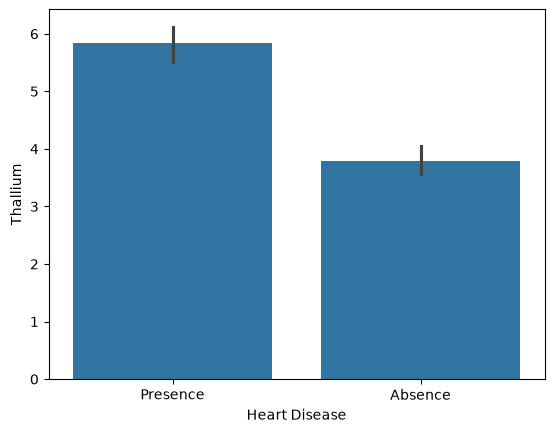

In [ ]:
sns.barplot(x=df['Heart Disease'],y=df['Thallium'],data=df)

<Axes: xlabel='Sex', ylabel='FBS over 120'>

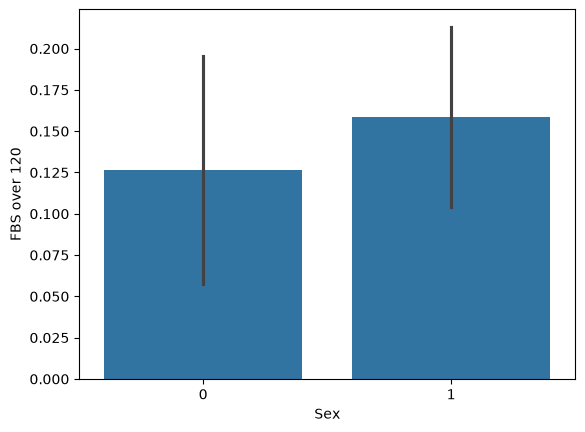

In [ ]:
sns.barplot(x=df['Sex'],y=df['FBS over 120'],data=df)

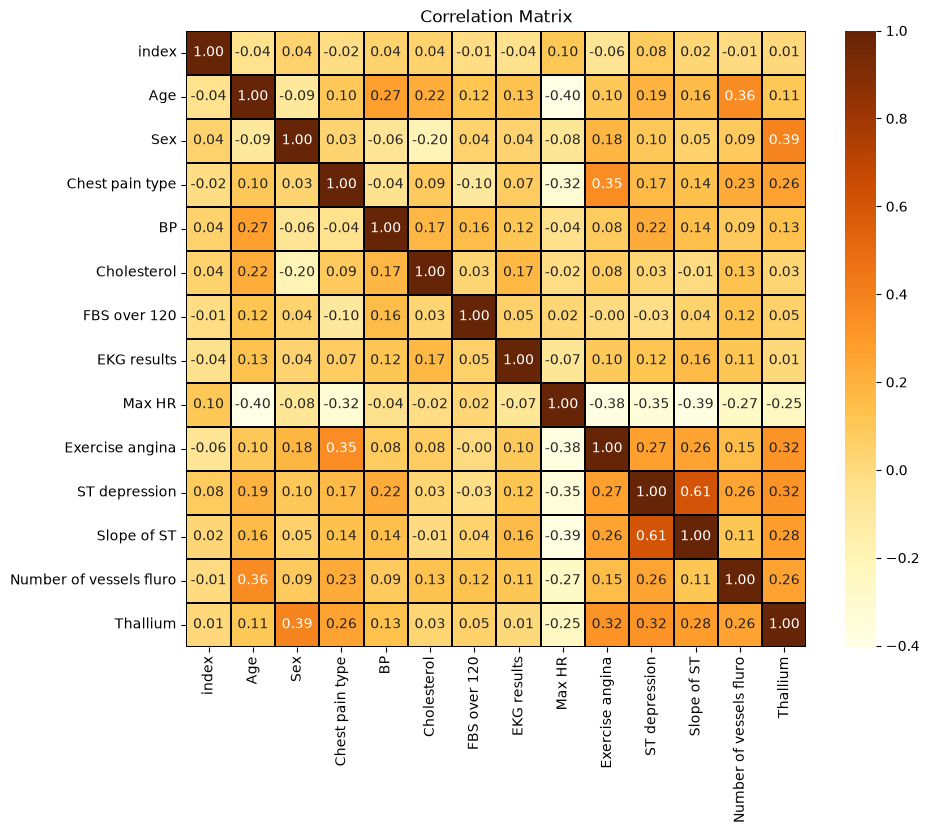

In [ ]:
# Create a correlation matrix
correlation_matrix = df.select_dtypes(include='number').corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True,linewidths= 0.2, linecolor= 'black', fmt=".2f", cmap="YlOrBr")
plt.title('Correlation Matrix')
plt.show()

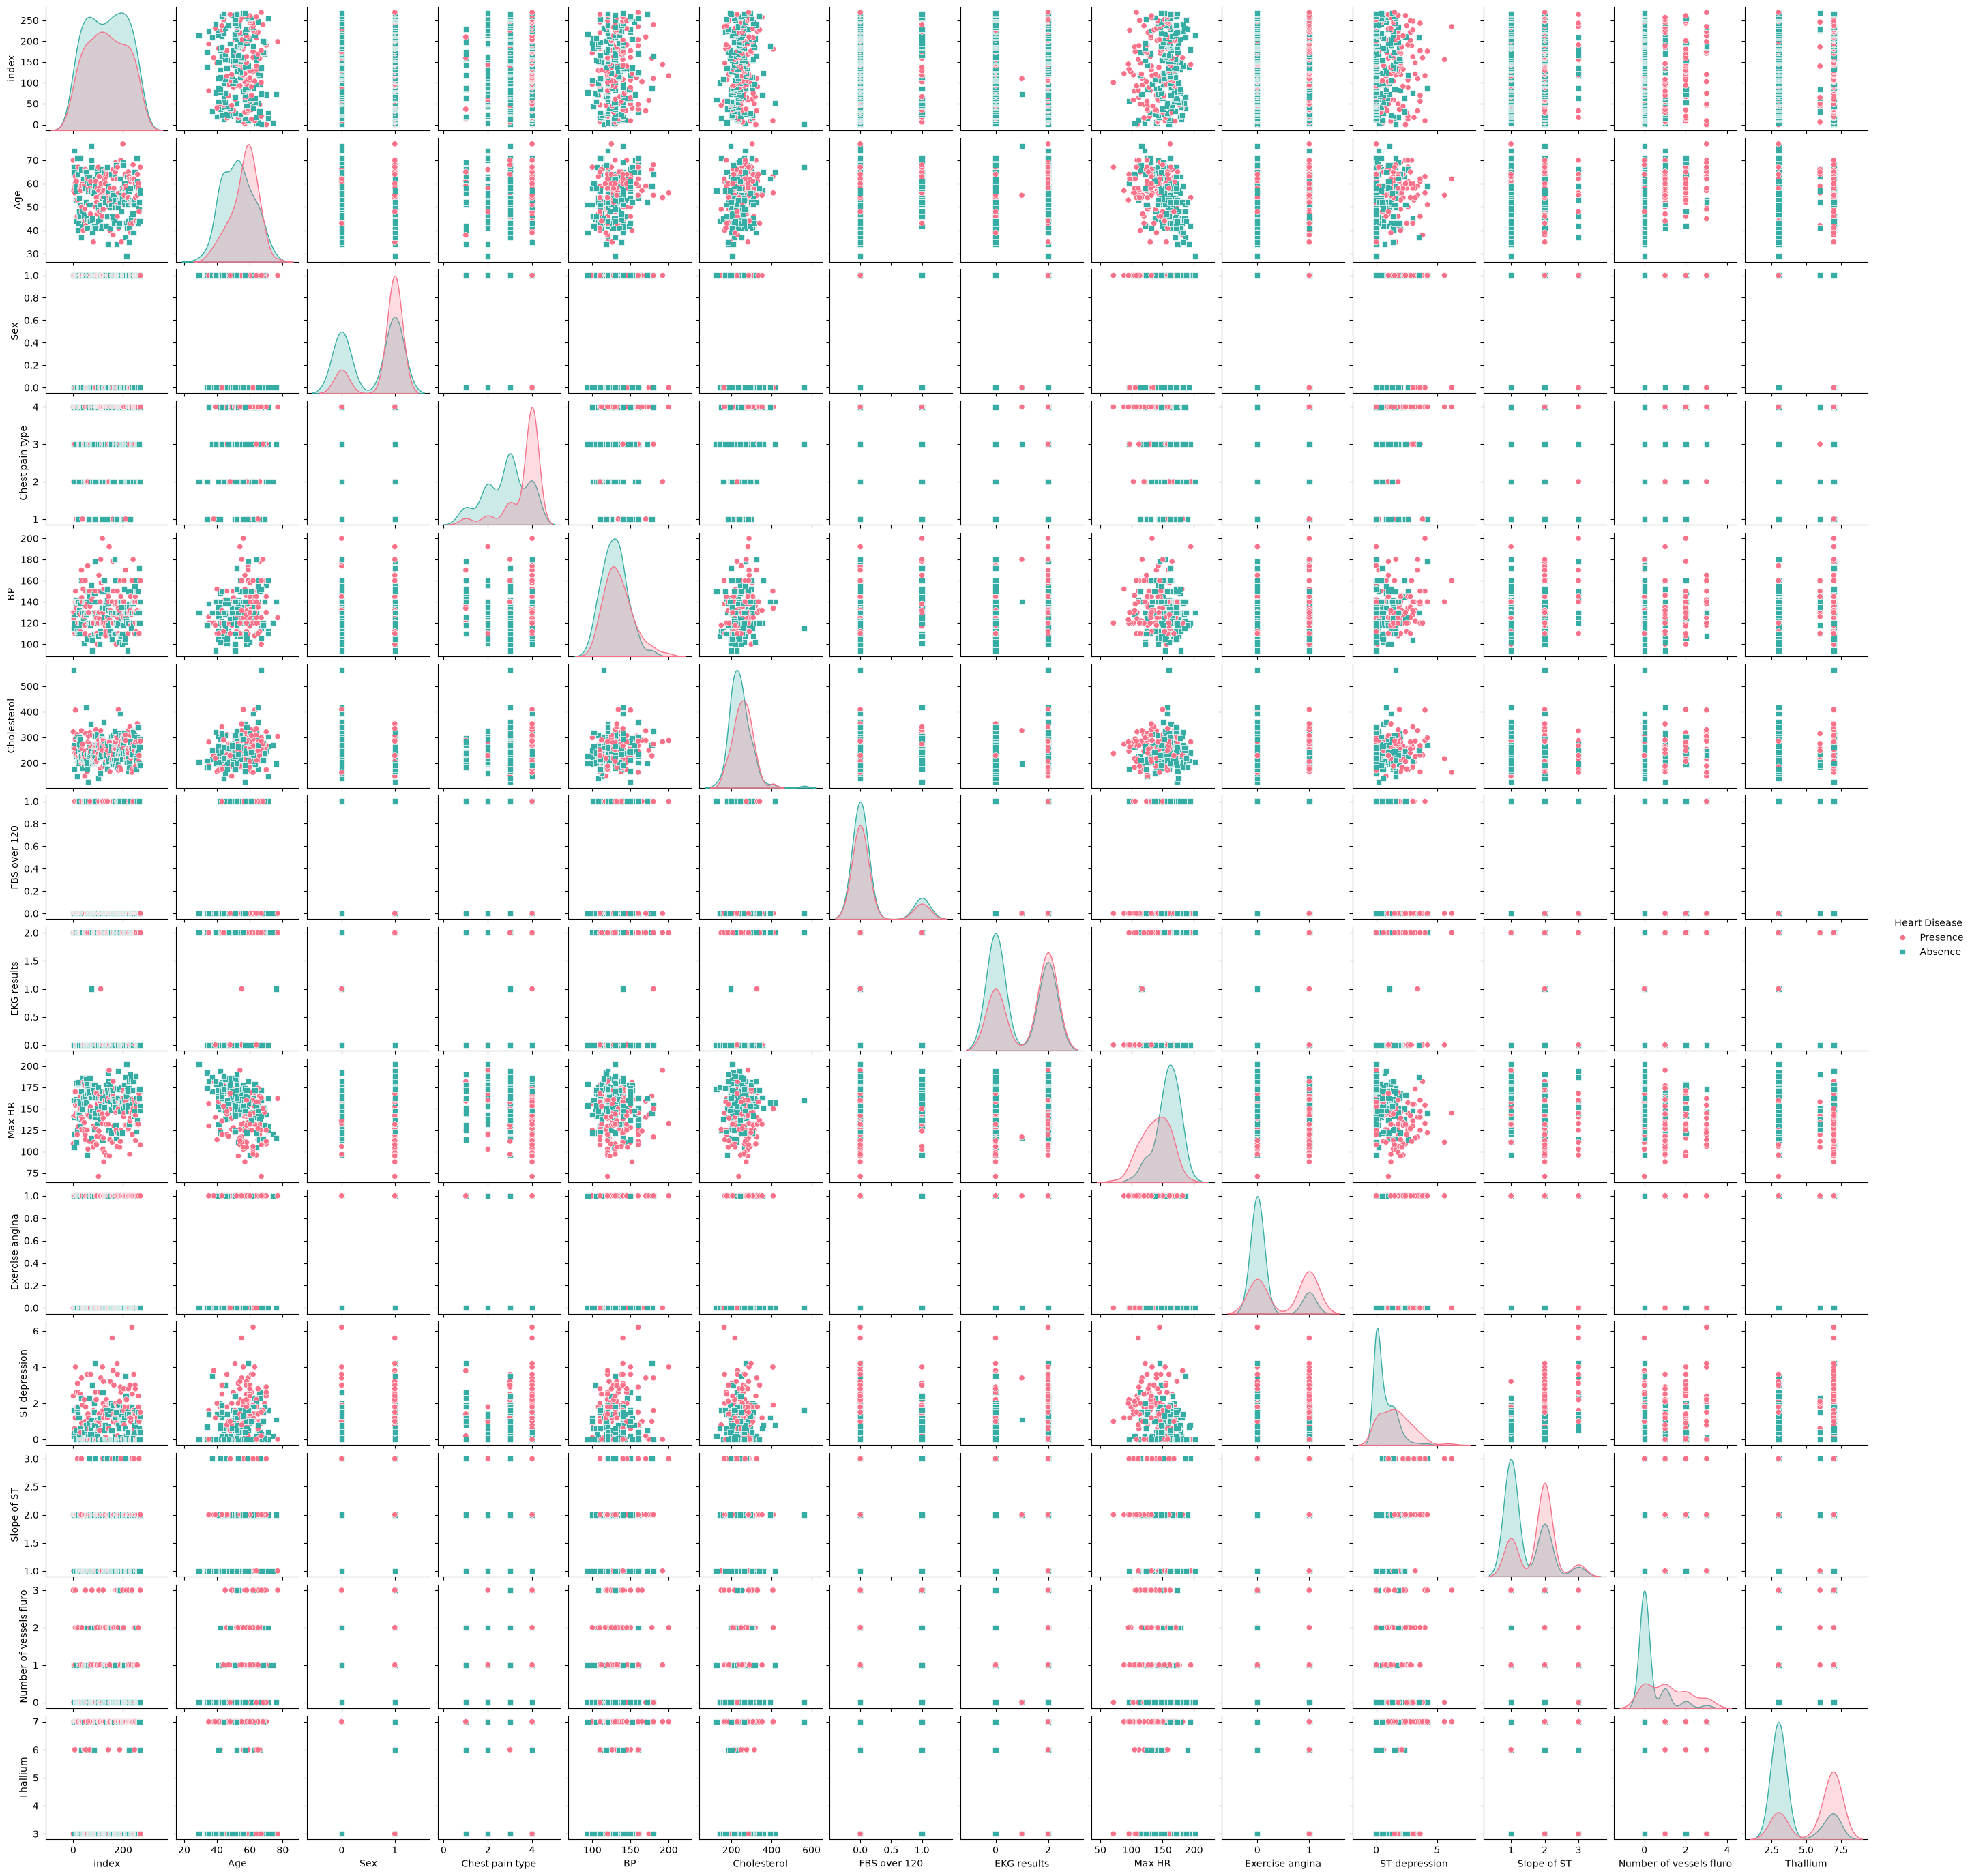

In [ ]:
sns.pairplot(df,hue='Heart Disease', diag_kind='kde', markers=["o", "s"], palette='husl', height=2)

In [ ]:
# DATA PREPROCESSING

# Separate features and target
X = df.drop(['Heart Disease', 'index'], axis=1)
y = df['Heart Disease']

# Convert categorical features into dummy variables
X = pd.get_dummies(
    X,
    columns=[
        'Sex',
        'Chest pain type',
        'EKG results',
        'Exercise angina',
        'Slope of ST',
        'Thallium'
    ]
)

# Save feature names
feature_columns = X.columns

print("Number of features:", len(feature_columns))
print("Features:")
print(feature_columns.tolist())

# TRAIN / VALIDATION / TEST SPLIT

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("\nTraining samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])
print("Testing samples:", X_test.shape[0])

# FEATURE SCALING

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

# MODEL DEVELOPMENT

models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42)
}

# MODEL TRAINING & TESTING

for name, model in models.items():

    print(f"\nTraining {name}...")

    # Train model
    model.fit(X_train_scaled, y_train)

    # Test prediction
    y_pred = model.predict(X_test_scaled)

    # Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(
        y_test, y_pred, average='weighted'
    )
    recall = recall_score(
        y_test, y_pred, average='weighted'
    )
    f1 = f1_score(
        y_test, y_pred, average='weighted'
    )

    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1 Score : {f1:.4f}")

Number of features: 24
Features:
['Age', 'BP', 'Cholesterol', 'FBS over 120', 'Max HR', 'ST depression', 'Number of vessels fluro', 'Sex_0', 'Sex_1', 'Chest pain type_1', 'Chest pain type_2', 'Chest pain type_3', 'Chest pain type_4', 'EKG results_0', 'EKG results_1', 'EKG results_2', 'Exercise angina_0', 'Exercise angina_1', 'Slope of ST_1', 'Slope of ST_2', 'Slope of ST_3', 'Thallium_3', 'Thallium_6', 'Thallium_7']

Training samples: 189
Validation samples: 40
Testing samples: 41

Training Logistic Regression...
Accuracy : 0.8780
Precision: 0.8797
Recall   : 0.8780
F1 Score : 0.8783

Training Decision Tree...
Accuracy : 0.8293
Precision: 0.8311
Recall   : 0.8293
F1 Score : 0.8297

Training Random Forest...
Accuracy : 0.8537
Precision: 0.8537
Recall   : 0.8537
F1 Score : 0.8537

Training Support Vector Machine...
Accuracy : 0.8537
Precision: 0.8588
Recall   : 0.8537
F1 Score : 0.8542


In [ ]:
# Convert categorical features to dummy variables 

X = pd.get_dummies(X, columns=['Sex', 'Chest pain type', 'EKG results', 'Exercise angina', 'Slope of ST', 'Thallium'])


In [ ]:
# Split the data into training and testing sets
# Assuming X and y are your features and target variable
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)


# Feature Selection

In [ ]:
# Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#  Model Development

In [ ]:
# Model Development
models = {
    'Logistic Regression': LogisticRegression(),
    'Decision Tree': DecisionTreeClassifier(),
    'Random Forest': RandomForestClassifier(),
    'Support Vector Machine': SVC()
}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Model Evaluation
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n{model}\nAccuracy: {accuracy:.4f}\nPrecision: {precision:.4f}\nRecall: {recall:.4f}\nF1 Score: {f1:.4f}\n")


Training Logistic Regression...

LogisticRegression()
Accuracy: 0.8049
Precision: 0.8569
Recall: 0.8049
F1 Score: 0.7939

Training Decision Tree...

DecisionTreeClassifier()
Accuracy: 0.7561
Precision: 0.7629
Recall: 0.7561
F1 Score: 0.7519

Training Random Forest...

RandomForestClassifier()
Accuracy: 0.8537
Precision: 0.8659
Recall: 0.8537
F1 Score: 0.8511

Training Support Vector Machine...

SVC()
Accuracy: 0.8293
Precision: 0.8477
Recall: 0.8293
F1 Score: 0.8250



# Cross-Validation

In [ ]:
# Cross-Validation
for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=5, scoring='accuracy')
    print(f"Cross-validation scores for {name}: {cv_scores}")
    print(f"Average Accuracy: {cv_scores.mean():.4f}\n")


Cross-validation scores for Logistic Regression: [0.7962963  0.83333333 0.90740741 0.87037037 0.88888889]
Average Accuracy: 0.8593

Cross-validation scores for Decision Tree: [0.57407407 0.74074074 0.75925926 0.66666667 0.74074074]
Average Accuracy: 0.6963

Cross-validation scores for Random Forest: [0.72222222 0.83333333 0.85185185 0.81481481 0.87037037]
Average Accuracy: 0.8185

Cross-validation scores for Support Vector Machine: [0.59259259 0.68518519 0.68518519 0.61111111 0.62962963]
Average Accuracy: 0.6407



# Hyperparameter Tuning

In [ ]:
# HYPERPARAMETER TUNING

from sklearn.pipeline import Pipeline

# Pipelines for each model
pipelines = {

    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(random_state=42))
    ]),

    'Decision Tree': Pipeline([
        ('scaler', StandardScaler()),
        ('model', DecisionTreeClassifier(random_state=42))
    ]),

    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=42))
    ]),

    'Support Vector Machine': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=42, probability=True))
    ])
}


# Hyperparameters to test
param_grids = {

    'Logistic Regression': {
        'model__C': [0.01, 0.1, 1, 10]
    },

    'Decision Tree': {
        'model__max_depth': [3, 5, 10, None],
        'model__min_samples_split': [2, 5, 10]
    },

    'Random Forest': {
        'model__n_estimators': [100, 200],
        'model__max_depth': [None, 5, 10],
        'model__min_samples_split': [2, 5]
    },

    'Support Vector Machine': {
        'model__C': [0.1, 1, 10],
        'model__kernel': ['linear', 'rbf']
    }
}


# Store the best models
best_models = {}


# Run GridSearchCV
for name in pipelines:

    print(f"\nTuning {name}...")

    grid_search = GridSearchCV(
        pipelines[name],
        param_grids[name],
        cv=5,
        scoring='accuracy',
        n_jobs=-1
    )

    # IMPORTANT: use training data only
    grid_search.fit(X_train, y_train)

    best_models[name] = grid_search.best_estimator_

    print("Best Parameters:", grid_search.best_params_)
    print("Best CV Accuracy:", round(grid_search.best_score_, 4))


Tuning Logistic Regression...
Best Parameters: {'model__C': 0.01}
Best CV Accuracy: 0.8094

Tuning Decision Tree...
Best Parameters: {'model__max_depth': 10, 'model__min_samples_split': 5}
Best CV Accuracy: 0.7619

Tuning Random Forest...
Best Parameters: {'model__max_depth': None, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best CV Accuracy: 0.8149

Tuning Support Vector Machine...
Best Parameters: {'model__C': 0.1, 'model__kernel': 'linear'}
Best CV Accuracy: 0.8041


In [ ]:
# EVALUATE TUNED MODELS

tuned_results = {}

for name, model in best_models.items():

    # Validation prediction
    y_val_pred = model.predict(X_val)

    # Test prediction
    y_test_pred = model.predict(X_test)

    # Calculate test metrics
    accuracy = accuracy_score(y_test, y_test_pred)

    precision = precision_score(
        y_test,
        y_test_pred,
        average='weighted'
    )

    recall = recall_score(
        y_test,
        y_test_pred,
        average='weighted'
    )

    f1 = f1_score(
        y_test,
        y_test_pred,
        average='weighted'
    )

    # Store results
    tuned_results[name] = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1 Score': f1
    }

    print(f"\n{name}")
    print("-" * 40)

    print(
        f"Validation Accuracy: "
        f"{accuracy_score(y_val, y_val_pred):.4f}"
    )

    print(f"Test Accuracy      : {accuracy:.4f}")
    print(f"Precision           : {precision:.4f}")
    print(f"Recall              : {recall:.4f}")
    print(f"F1 Score            : {f1:.4f}")


Logistic Regression
----------------------------------------
Validation Accuracy: 0.8750
Test Accuracy      : 0.8537
Precision           : 0.8588
Recall              : 0.8537
F1 Score            : 0.8542

Decision Tree
----------------------------------------
Validation Accuracy: 0.7500
Test Accuracy      : 0.8537
Precision           : 0.8588
Recall              : 0.8537
F1 Score            : 0.8542

Random Forest
----------------------------------------
Validation Accuracy: 0.8750
Test Accuracy      : 0.8293
Precision           : 0.8311
Recall              : 0.8293
F1 Score            : 0.8297

Support Vector Machine
----------------------------------------
Validation Accuracy: 0.9250
Test Accuracy      : 0.8780
Precision           : 0.8797
Recall              : 0.8780
F1 Score            : 0.8783


# Validation and Testing

In [ ]:
# Validation and Testing
for name, model in models.items():
    print(f"Testing {name} on validation set...")
    y_val_pred = model.predict(X_val)

    # Model Evaluation on Validation Set
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, average='weighted')
    val_recall = recall_score(y_val, y_val_pred, average='weighted')
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    print(f"\n{model}\nValidation Accuracy: {val_accuracy:.4f}\nValidation Precision: {val_precision:.4f}\nValidation Recall: {val_recall:.4f}\nValidation F1 Score: {val_f1:.4f}\n")

    # Testing
    print(f"Testing {name} on test set...")
    y_test_pred = model.predict(X_test)

    # Model Evaluation on Test Set
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted')
    test_recall = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')

    print(f"\n{model}\nTest Accuracy: {test_accuracy:.4f}\nTest Precision: {test_precision:.4f}\nTest Recall: {test_recall:.4f}\nTest F1 Score: {test_f1:.4f}\n")


Testing Logistic Regression on validation set...

LogisticRegression()
Validation Accuracy: 0.3250
Validation Precision: 0.1056
Validation Recall: 0.3250
Validation F1 Score: 0.1594

Testing Logistic Regression on test set...

LogisticRegression()
Test Accuracy: 0.8049
Test Precision: 0.8569
Test Recall: 0.8049
Test F1 Score: 0.7939

Testing Decision Tree on validation set...

DecisionTreeClassifier()
Validation Accuracy: 0.6750
Validation Precision: 0.4556
Validation Recall: 0.6750
Validation F1 Score: 0.5440

Testing Decision Tree on test set...

DecisionTreeClassifier()
Test Accuracy: 0.7561
Test Precision: 0.7629
Test Recall: 0.7561
Test F1 Score: 0.7519

Testing Random Forest on validation set...

RandomForestClassifier()
Validation Accuracy: 0.6000
Validation Precision: 0.6511
Validation Recall: 0.6000
Validation F1 Score: 0.6125

Testing Random Forest on test set...

RandomForestClassifier()
Test Accuracy: 0.8537
Test Precision: 0.8659
Test Recall: 0.8537
Test F1 Score: 0.8511



Testing Logistic Regression on validation set...
Testing Logistic Regression on test set...


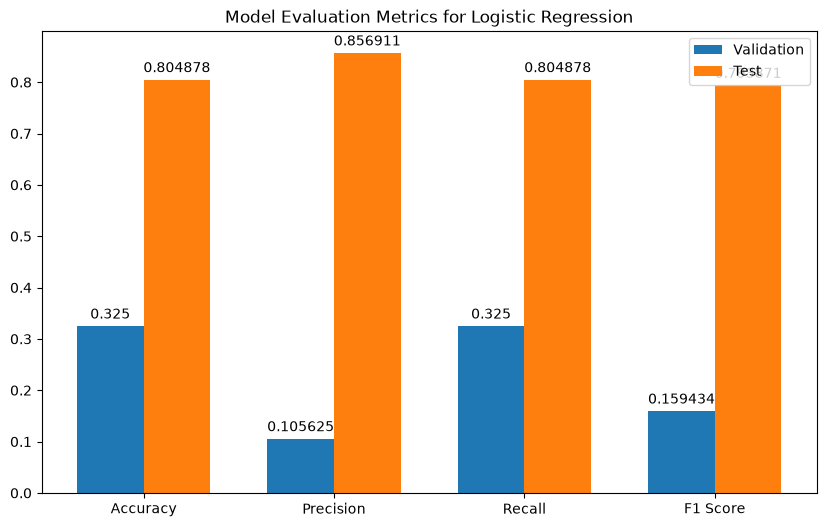

Testing Decision Tree on validation set...
Testing Decision Tree on test set...


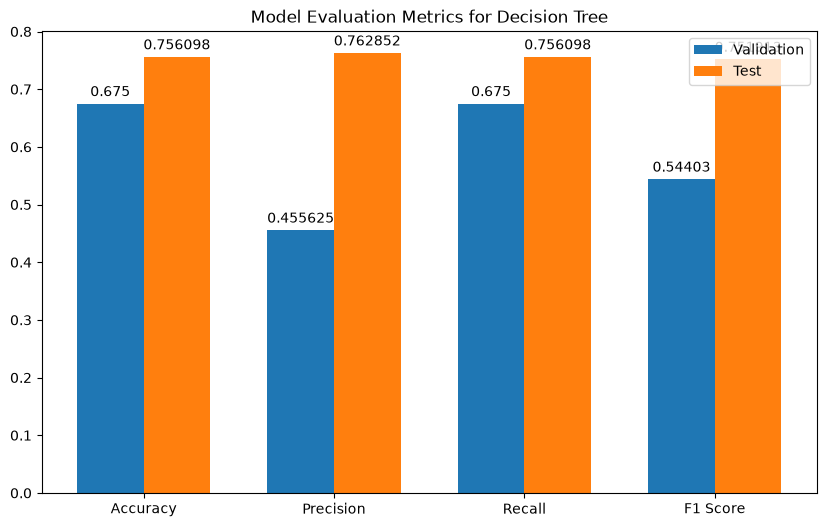

Testing Random Forest on validation set...
Testing Random Forest on test set...


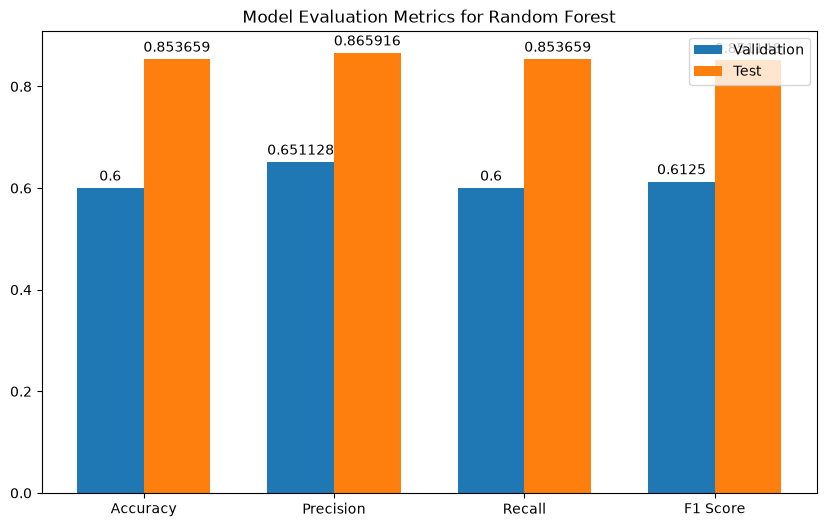

Testing Support Vector Machine on validation set...
Testing Support Vector Machine on test set...


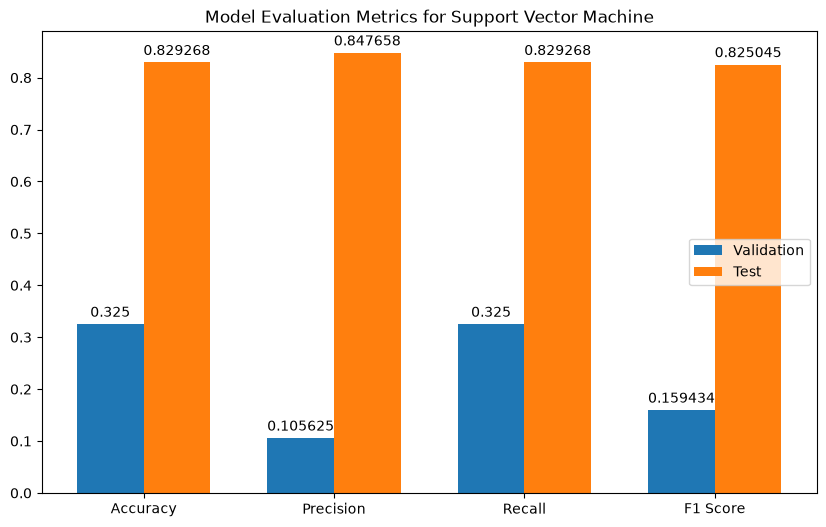

In [ ]:
# Validation and Testing
for name, model in models.items():
    print(f"Testing {name} on validation set...")
    y_val_pred = model.predict(X_val)

    # Model Evaluation on Validation Set
    val_accuracy = accuracy_score(y_val, y_val_pred)
    val_precision = precision_score(y_val, y_val_pred, average='weighted')
    val_recall = recall_score(y_val, y_val_pred, average='weighted')
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    # Testing
    print(f"Testing {name} on test set...")
    y_test_pred = model.predict(X_test)

    # Model Evaluation on Test Set
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_precision = precision_score(y_test, y_test_pred, average='weighted')
    test_recall = recall_score(y_test, y_test_pred, average='weighted')
    test_f1 = f1_score(y_test, y_test_pred, average='weighted')

    # Plotting
    metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
    val_scores = [val_accuracy, val_precision, val_recall, val_f1]
    test_scores = [test_accuracy, test_precision, test_recall, test_f1]

    x = np.arange(len(metrics))
    width = 0.35

    fig, ax = plt.subplots(figsize=(10, 6))
    rects1 = ax.bar(x - width/2, val_scores, width, label='Validation')
    rects2 = ax.bar(x + width/2, test_scores, width, label='Test')

    ax.set_xticks(x)
    ax.set_xticklabels(metrics)
    ax.legend()

    ax.bar_label(rects1, padding=3)
    ax.bar_label(rects2, padding=3)

    plt.title(f'Model Evaluation Metrics for {name}')
    plt.show()


# Confusion Matrix

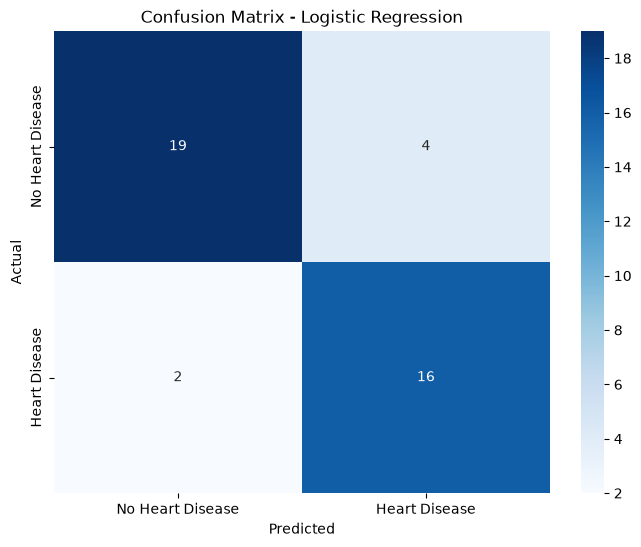

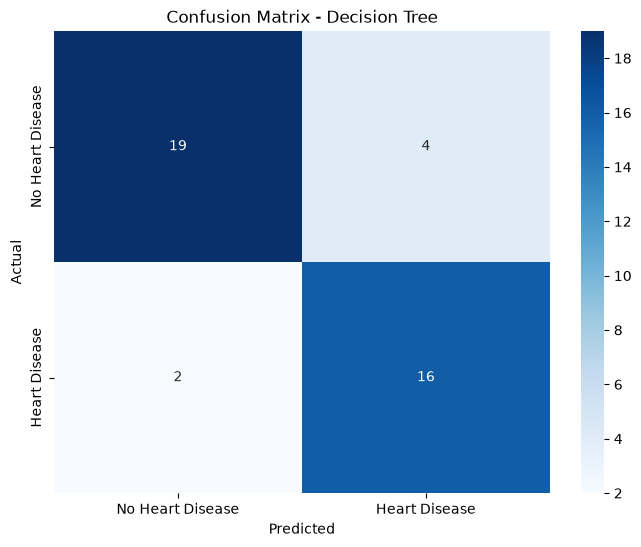

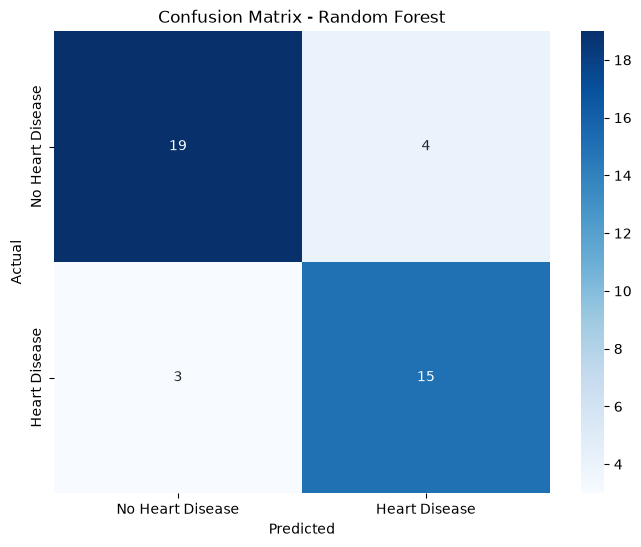

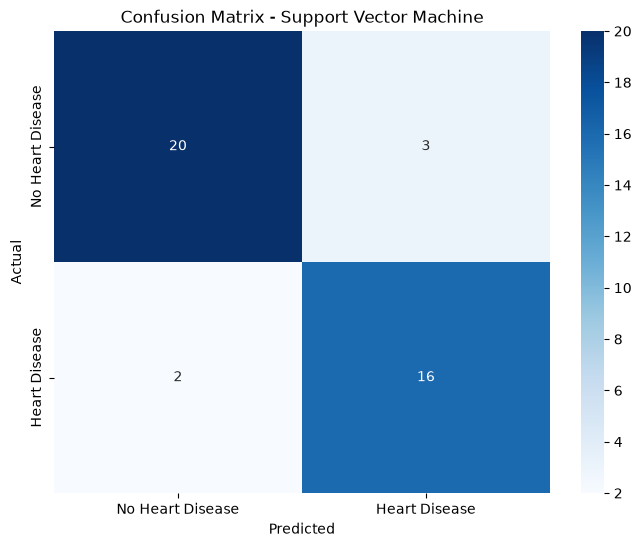

In [ ]:
# Confusion Matrix for each tuned model

for name, model in best_models.items():

    # Predictions on test set
    y_pred = model.predict(X_test)

    # Generate confusion matrix
    cm = confusion_matrix(y_test, y_pred)

    # Plot confusion matrix
    plt.figure(figsize=(8, 6))

    sns.heatmap(
        cm,
        annot=True,
        cmap='Blues',
        fmt='g',
        xticklabels=['No Heart Disease', 'Heart Disease'],
        yticklabels=['No Heart Disease', 'Heart Disease']
    )

    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

In [ ]:
# MODEL COMPARISON

results_df = pd.DataFrame(tuned_results).T

results_df = results_df.round(4)

print("Model Performance Comparison:")
display(results_df)

Model Performance Comparison:


,Accuracy,Precision,Recall,F1 Score
Logistic Regression,0.8537,0.8588,0.8537,0.8542
Decision Tree,0.8537,0.8588,0.8537,0.8542
Random Forest,0.8293,0.8311,0.8293,0.8297
Support Vector Machine,0.8780,0.8797,0.8780,0.8783


In [ ]:
# CLASSIFICATION REPORT

from sklearn.metrics import classification_report

for name, model in best_models.items():

    y_test_pred = model.predict(X_test)

    print(f"\n{name}")
    print("=" * 50)

    print(
        classification_report(
            y_test,
            y_test_pred
        )
    )


Logistic Regression
              precision    recall  f1-score   support

     Absence       0.90      0.83      0.86        23
    Presence       0.80      0.89      0.84        18

    accuracy                           0.85        41
   macro avg       0.85      0.86      0.85        41
weighted avg       0.86      0.85      0.85        41


Decision Tree
              precision    recall  f1-score   support

     Absence       0.90      0.83      0.86        23
    Presence       0.80      0.89      0.84        18

    accuracy                           0.85        41
   macro avg       0.85      0.86      0.85        41
weighted avg       0.86      0.85      0.85        41


Random Forest
              precision    recall  f1-score   support

     Absence       0.86      0.83      0.84        23
    Presence       0.79      0.83      0.81        18

    accuracy                           0.83        41
   macro avg       0.83      0.83      0.83        41
weighted avg       0.83

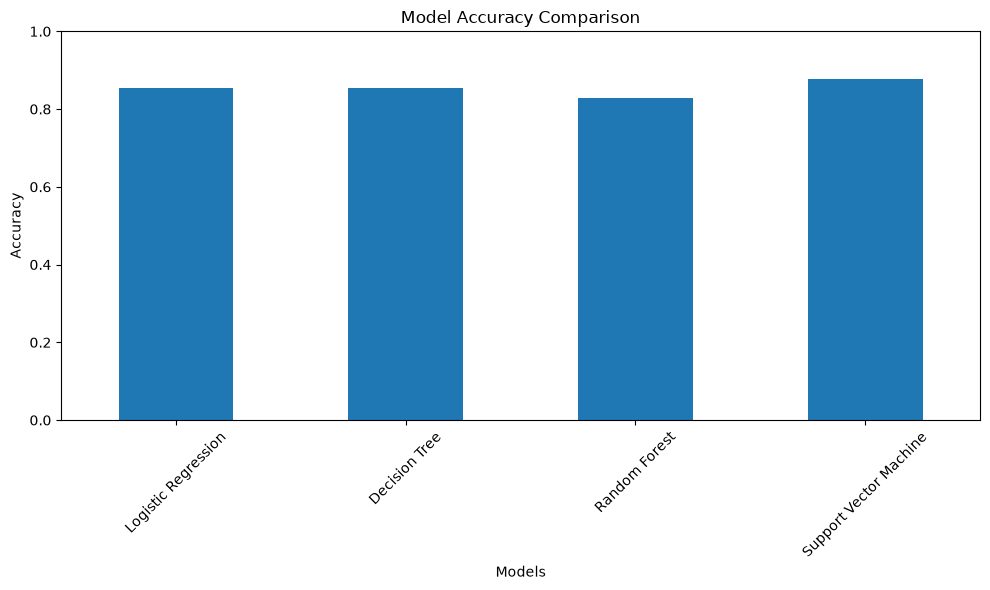

In [ ]:
# MODEL ACCURACY COMPARISON

plt.figure(figsize=(10, 6))

results_df['Accuracy'].plot(
    kind='bar'
)

plt.title('Model Accuracy Comparison')
plt.xlabel('Models')
plt.ylabel('Accuracy')

plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.tight_layout()
plt.show()

# Model Interpretability

In [ ]:
print(type(shap_values))
print(shap_values.shape if hasattr(shap_values, "shape") else "No shape")
print(type(explainer.expected_value))
print(explainer.expected_value)

<class 'numpy.ndarray'>
(270, 25, 2)
<class 'numpy.ndarray'>
[0.55562963 0.44437037]


In [ ]:
print("SHAP type:", type(shap_values))

if hasattr(shap_values, "shape"):
    print("SHAP shape:", shap_values.shape)

print("Expected value:", explainer.expected_value)
print("X shape:", X.shape)
print("Number of features:", len(X.columns))

SHAP type: <class 'numpy.ndarray'>
SHAP shape: (270, 25, 2)
Expected value: [0.55562963 0.44437037]
X shape: (270, 25)
Number of features: 25


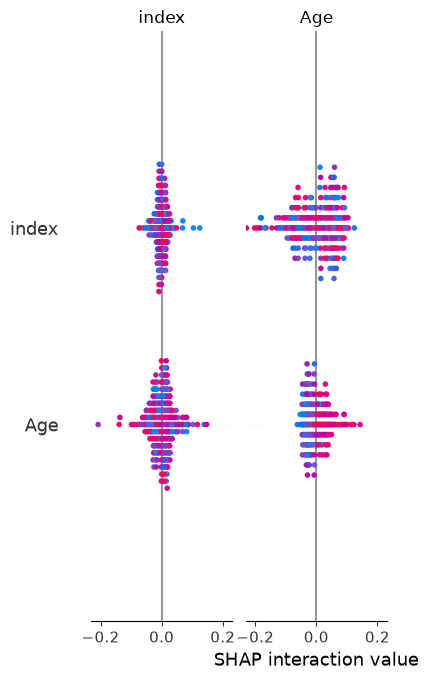

In [ ]:
# Select a model for SHAP values interpretation
model_for_shap = RandomForestClassifier()

# Train the model on the entire dataset
model_for_shap.fit(X, y)

# Use SHAP values to explain the model predictions
explainer = shap.TreeExplainer(model_for_shap)
shap_values = explainer.shap_values(X)

# Summary Plot for Feature Importance
shap.summary_plot(
    shap_values,
    X,
    feature_names=X.columns,
    plot_type='bar'
)

# Individual SHAP Values Plot
instance_index = 1

shap.force_plot(
    explainer.expected_value[1],
    shap_values[instance_index, :, 1],
    X.iloc[instance_index, :],
    feature_names=X.columns
)

In [ ]:
# DEPLOYMENT-SAFE FINAL PIPELINE

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC

# Raw features
X_raw = df.drop(['Heart Disease', 'index'], axis=1)
y_raw = df['Heart Disease']

# Numerical features
numeric_features = [
    'Age',
    'BP',
    'Cholesterol',
    'FBS over 120',
    'Max HR',
    'ST depression',
    'Number of vessels fluro'
]

# Categorical features
categorical_features = [
    'Sex',
    'Chest pain type',
    'EKG results',
    'Exercise angina',
    'Slope of ST',
    'Thallium'
]

# Same train/validation/test split
X_train_raw, X_temp_raw, y_train_raw, y_temp_raw = train_test_split(
    X_raw,
    y_raw,
    test_size=0.30,
    random_state=42,
    stratify=y_raw
)

X_val_raw, X_test_raw, y_val_raw, y_test_raw = train_test_split(
    X_temp_raw,
    y_temp_raw,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_raw
)

# Preprocessing
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False
    ), categorical_features)
])

# Final SVM pipeline
final_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVC(
        C=0.1,
        kernel='linear',
        probability=True,
        random_state=42
    ))
])

# Train
final_pipeline.fit(X_train_raw, y_train_raw)

# Test
y_test_final = final_pipeline.predict(X_test_raw)

print("Final SVM Test Accuracy:",
      round(accuracy_score(y_test_raw, y_test_final), 4))

print("\nClassification Report:")
print(classification_report(y_test_raw, y_test_final))

Final SVM Test Accuracy: 0.8537

Classification Report:
              precision    recall  f1-score   support

     Absence       0.84      0.91      0.88        23
    Presence       0.88      0.78      0.82        18

    accuracy                           0.85        41
   macro avg       0.86      0.85      0.85        41
weighted avg       0.86      0.85      0.85        41



In [ ]:
# SAVE FINAL MODEL

import joblib

# Train final pipeline on the complete dataset
final_pipeline.fit(X_raw, y_raw)

# Save the complete pipeline
joblib.dump(final_pipeline, 'heart_disease_model.pkl')

print("Final model saved successfully!")
print("File: heart_disease_model.pkl")

Final model saved successfully!
File: heart_disease_model.pkl
